# NB4 — Psychometrics & Motivation Analysis

**Purpose**: Link personality traits (Big Five) and IQ to task performance.  
Covers IQ=0 analysis, Big5 correlations, personality profiles, and predictive modeling.

> **Note**: Only 58 of 68 participants have psychometric data.  
> The 10 TG=1 dropouts have no Big5/IQ scores and are excluded from all analyses here.

---

In [1]:
# ── Imports & Setup ──
import sys, os, warnings
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from helpers import (
    load_and_clean, derive_variables, get_participant_summary,
    setup_plotting, COLORS, CONDITION_PALETTE, add_significance
)

plt, sns = setup_plotting()

df = load_and_clean()
df = derive_variables(df)
ps = get_participant_summary(df)

# Filter to participants WITH psychometric data
ps_psycho = ps[ps['has_psychometrics']].copy()
print(f'Participants with psychometrics: {len(ps_psycho)} / {len(ps)}')
print(f'  Completers: {ps_psycho["is_completer"].sum()}')
print(f'  Dropouts: {(~ps_psycho["is_completer"]).sum()}')

Participants with psychometrics: 58 / 68
  Completers: 51
  Dropouts: 7


## 1. IQ Score Analysis

31 of 58 participants scored IQ=0. Is this a motivation issue?

=== IQ Score Distribution ===
count    58.000000
mean      1.155172
std       1.641584
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max       6.000000
Name: iq_score, dtype: float64

IQ=0: 31 (53.4%)
IQ>0: 27 (46.6%)


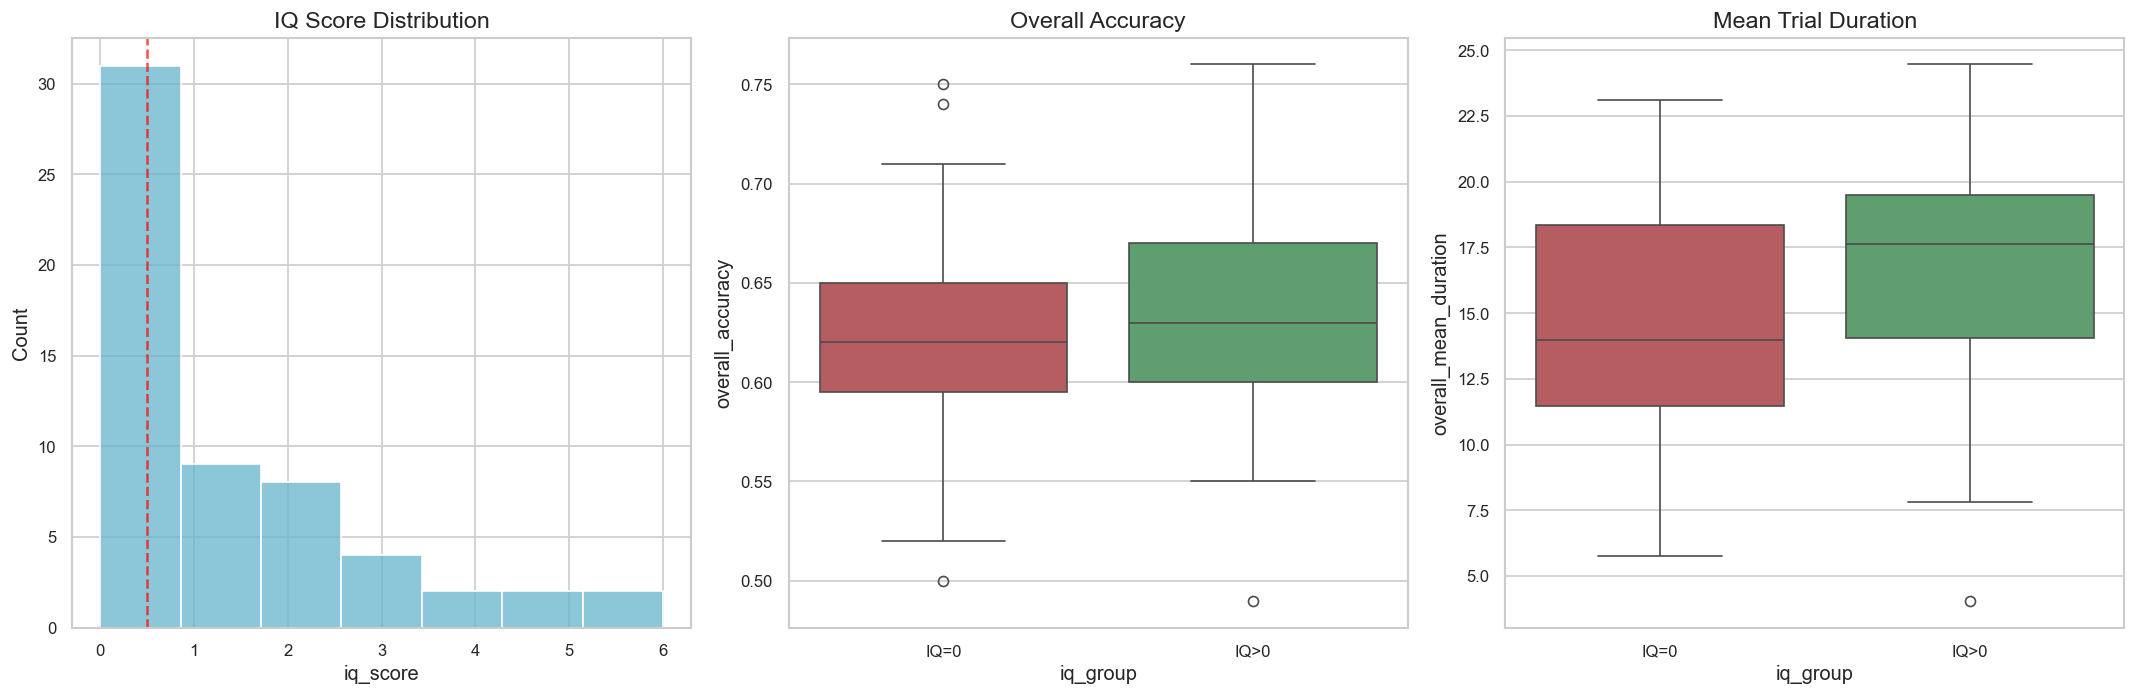

In [2]:
# IQ distribution
ps_psycho['iq_group'] = ps_psycho['iq_score'].apply(lambda x: 'IQ=0' if x == 0 else 'IQ>0')

print('=== IQ Score Distribution ===')
print(ps_psycho['iq_score'].describe())
print(f'\nIQ=0: {(ps_psycho["iq_score"] == 0).sum()} ({(ps_psycho["iq_score"] == 0).mean()*100:.1f}%)')
print(f'IQ>0: {(ps_psycho["iq_score"] > 0).sum()} ({(ps_psycho["iq_score"] > 0).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# IQ histogram
sns.histplot(data=ps_psycho, x='iq_score', bins=7, ax=axes[0], color=COLORS['neutral'])
axes[0].set_title('IQ Score Distribution')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7)

# IQ=0 vs IQ>0: accuracy comparison
for metric, ax, title in [
    ('overall_accuracy', axes[1], 'Overall Accuracy'),
    ('overall_mean_duration', axes[2], 'Mean Trial Duration')
]:
    sns.boxplot(data=ps_psycho, x='iq_group', y=metric, ax=ax,
              palette=[COLORS['incorrect'], COLORS['correct']], order=['IQ=0', 'IQ>0'])
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [3]:
# Comprehensive IQ=0 vs IQ>0 comparison
iq0 = ps_psycho[ps_psycho['iq_group'] == 'IQ=0']
iq_pos = ps_psycho[ps_psycho['iq_group'] == 'IQ>0']

print('=== IQ=0 vs IQ>0 Comprehensive Comparison ===')
metrics = [
    ('overall_accuracy', 'Overall Accuracy'),
    ('control_accuracy', 'Control Accuracy'),
    ('ai_accuracy', 'AI Accuracy'),
    ('overall_mean_duration', 'Mean Duration (s)'),
    ('over_reliance_rate', 'Over-reliance Rate'),
    ('skepticism_rate', 'Skepticism Rate'),
    ('decision_change_rate', 'Decision Change Rate'),
]

comparison_results = []
for col, label in metrics:
    g0 = iq0[col].dropna()
    g1 = iq_pos[col].dropna()
    if len(g0) > 1 and len(g1) > 1:
        t, p = stats.ttest_ind(g1, g0)
        d = pg.compute_effsize(g1, g0, eftype='cohen')
        comparison_results.append({
            'Metric': label,
            'IQ=0 (mean±SD)': f'{g0.mean():.3f}±{g0.std():.3f}',
            'IQ>0 (mean±SD)': f'{g1.mean():.3f}±{g1.std():.3f}',
            't': f'{t:.2f}',
            'p': f'{p:.4f}',
            'd': f'{d:.2f}',
            'sig': '*' if p < 0.05 else ''
        })

display(pd.DataFrame(comparison_results))

=== IQ=0 vs IQ>0 Comprehensive Comparison ===


,Metric,IQ=0 (mean±SD),IQ>0 (mean±SD),t,p,d,sig
0,Overall Accuracy,0.624±0.057,0.632±0.062,0.51,0.6105,0.13,
1,Control Accuracy,0.606±0.071,0.607±0.069,0.05,0.9629,0.01,
2,AI Accuracy,0.647±0.090,0.659±0.090,0.46,0.6443,0.13,
3,Mean Duration (s),14.462±4.567,16.461±4.772,1.63,0.1091,0.43,
4,Over-reliance Rate,0.152±0.032,0.160±0.044,0.76,0.4504,0.21,
5,Skepticism Rate,0.201±0.094,0.181±0.080,-0.81,0.4233,-0.23,
6,Decision Change Rate,0.087±0.083,0.105±0.079,0.81,0.4239,0.23,


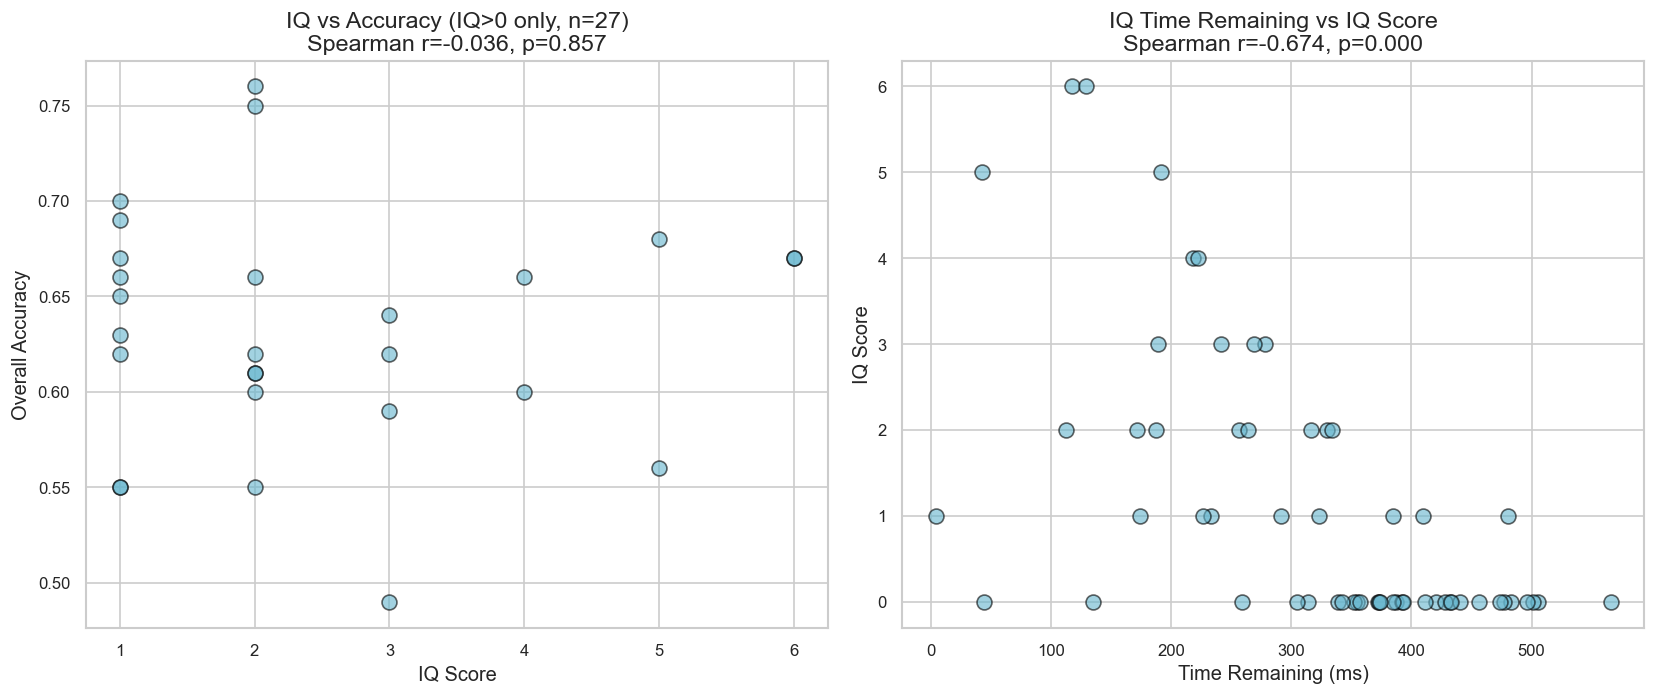

=== Statistical Tests: IQ Score as Continuous Predictor ===
1. IQ vs Accuracy (IQ>0): Spearman r=-0.036, p=0.857
2. IQ Time Remaining vs IQ Score: Spearman r=-0.674, p=0.000

=== OLS Regression: Overall Accuracy ~ IQ Score (IQ>0) ===
           Coef.  Std.Err.        t   P>|t|  [0.025  0.975]
const     0.6316    0.0228  27.6937  0.0000  0.5847  0.6786
iq_score  0.0001    0.0078   0.0117  0.9907 -0.0160  0.0162


In [4]:
# IQ score as continuous predictor (for IQ>0 group)
iq_positive = ps_psycho[ps_psycho['iq_score'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# IQ vs accuracy (IQ>0 only)
axes[0].scatter(iq_positive['iq_score'], iq_positive['overall_accuracy'],
              alpha=0.6, color=COLORS['neutral'], edgecolor='black', s=80)
r1, p1 = stats.spearmanr(iq_positive['iq_score'], iq_positive['overall_accuracy'])
axes[0].set_title(f'IQ vs Accuracy (IQ>0 only, n={len(iq_positive)})\nSpearman r={r1:.3f}, p={p1:.3f}')
axes[0].set_xlabel('IQ Score')
axes[0].set_ylabel('Overall Accuracy')

# IQ time remaining as motivation proxy
ps_psycho['iq_time_remaining'] = df.groupby('participant_id')['iq_time_remaining'].first().reindex(ps_psycho['participant_id']).values
axes[1].scatter(ps_psycho['iq_time_remaining'], ps_psycho['iq_score'],
              alpha=0.6, color=COLORS['neutral'], edgecolor='black', s=80)
r2, p2 = stats.spearmanr(ps_psycho['iq_time_remaining'], ps_psycho['iq_score'])
axes[1].set_title(f'IQ Time Remaining vs IQ Score\nSpearman r={r2:.3f}, p={p2:.3f}')
axes[1].set_xlabel('Time Remaining (ms)')
axes[1].set_ylabel('IQ Score')

plt.tight_layout()
plt.show()

print('=== Statistical Tests: IQ Score as Continuous Predictor ===')
print(f'1. IQ vs Accuracy (IQ>0): Spearman r={r1:.3f}, p={p1:.3f}')
print(f'2. IQ Time Remaining vs IQ Score: Spearman r={r2:.3f}, p={p2:.3f}')

import statsmodels.api as sm
X = sm.add_constant(iq_positive['iq_score'])
model_iq = sm.OLS(iq_positive['overall_accuracy'], X).fit()
print('\n=== OLS Regression: Overall Accuracy ~ IQ Score (IQ>0) ===')
print(model_iq.summary2().tables[1].round(4))


## 2a. Big Five Personality Correlations

In [5]:
# Big 5 trait correlations with performance
b5_cols = ['big5_agreeableness', 'big5_conscientiousness', 'big5_extraversion',
           'big5_neuroticism', 'big5_open_mindedness']
b5_labels = [c.replace('big5_', '').capitalize() for c in b5_cols]

perf_cols = ['overall_accuracy', 'control_accuracy', 'ai_accuracy', 
             'over_reliance_rate', 'skepticism_rate', 'overall_mean_duration']
perf_labels = ['Overall Acc', 'Control Acc', 'AI Acc', 
               'Over-reliance', 'Skepticism', 'Mean Duration']

# Correlation matrix
corr_results = []
for b5, b5_label in zip(b5_cols, b5_labels):
    for perf, perf_label in zip(perf_cols, perf_labels):
        valid = ps_psycho[[b5, perf]].dropna()
        if len(valid) > 5:
            r, p = stats.spearmanr(valid[b5], valid[perf])
            corr_results.append({
                'Big5 Trait': b5_label,
                'Performance Metric': perf_label,
                'r': r,
                'p': p,
                'n': len(valid),
                'sig': '*' if p < 0.05 else ('†' if p < 0.1 else '')
            })

corr_df = pd.DataFrame(corr_results)
print('=== Big Five × Performance Correlations (Spearman) ===')
display(corr_df.round(3))

# Highlight significant correlations
print('\n=== Highlight: Significant & Marginal Correlations (p < 0.1) ===')
sig_corrs = corr_df[corr_df['p'] < 0.1]
if len(sig_corrs) > 0:
    for _, row in sig_corrs.iterrows():
        marker = '**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else '†')
        print(f'  {row["Big5 Trait"]} x {row["Performance Metric"]}: r={row["r"]:.3f}, p={row["p"]:.4f} {marker}')
else:
    print('\nNo significant correlations at p < 0.1')


=== Big Five × Performance Correlations (Spearman) ===


,Big5 Trait,Performance Metric,r,p,n,sig
0,Agreeableness,Overall Acc,-0.087,0.518,58,
1,Agreeableness,Control Acc,-0.192,0.148,58,
2,Agreeableness,AI Acc,0.048,0.740,51,
3,Agreeableness,Over-reliance,-0.104,0.466,51,
4,Agreeableness,Skepticism,-0.005,0.975,51,
5,Agreeableness,Mean Duration,0.120,0.372,58,
6,Conscientiousness,Overall Acc,0.169,0.206,58,
7,Conscientiousness,Control Acc,0.092,0.491,58,
8,Conscientiousness,AI Acc,0.164,0.251,51,
9,Conscientiousness,Over-reliance,-0.175,0.219,51,



=== Highlight: Significant & Marginal Correlations (p < 0.1) ===
  Extraversion x Overall Acc: r=-0.422, p=0.0010 **
  Extraversion x AI Acc: r=-0.516, p=0.0001 **
  Extraversion x Skepticism: r=0.425, p=0.0019 **
  Neuroticism x Skepticism: r=0.264, p=0.0616 †
  Open_mindedness x Mean Duration: r=0.258, p=0.0504 †


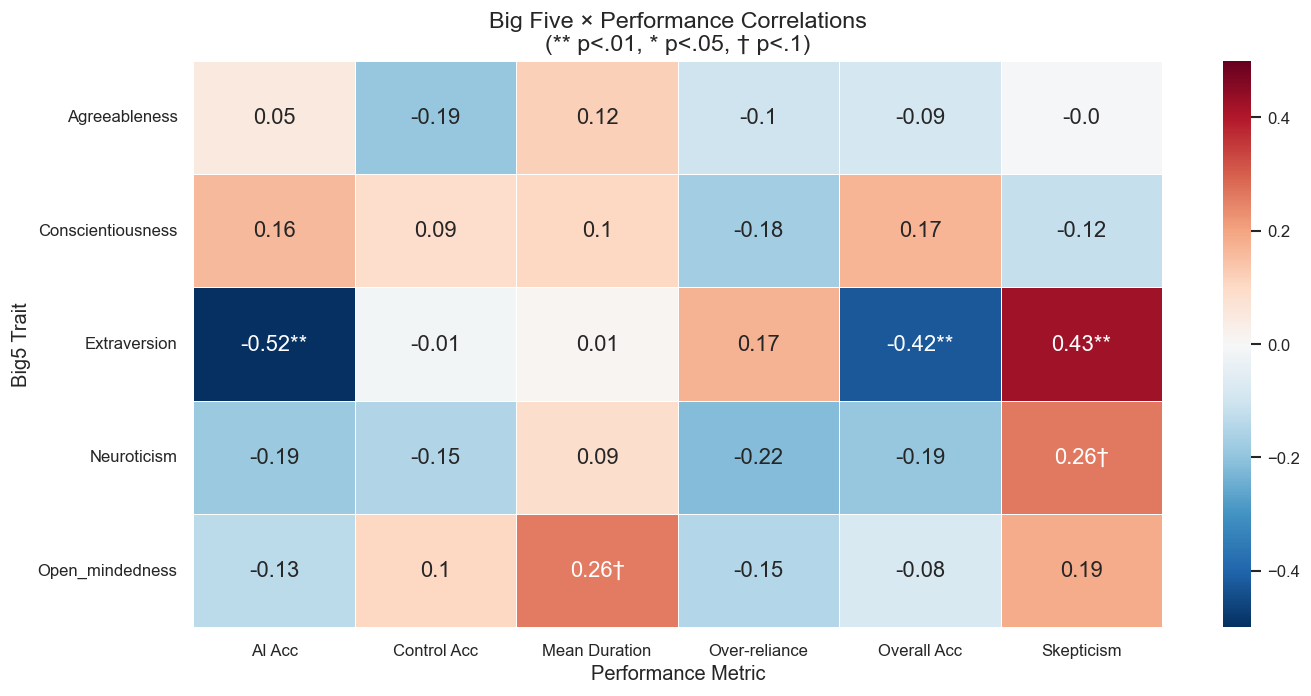

In [6]:
# Visualization: correlation heatmap
corr_matrix = corr_df.pivot_table(index='Big5 Trait', columns='Performance Metric', values='r')
p_matrix = corr_df.pivot_table(index='Big5 Trait', columns='Performance Metric', values='p')

fig, ax = plt.subplots(figsize=(12, 6))

# Create annotation with stars
annot = corr_matrix.round(2).astype(str)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        p_val = p_matrix.iloc[i, j]
        if p_val < 0.01:
            annot.iloc[i, j] += '**'
        elif p_val < 0.05:
            annot.iloc[i, j] += '*'
        elif p_val < 0.1:
            annot.iloc[i, j] += '†'

sns.heatmap(corr_matrix, annot=annot, fmt='s', cmap='RdBu_r', center=0,
           vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5)
ax.set_title('Big Five × Performance Correlations\n(** p<.01, * p<.05, † p<.1)')

plt.tight_layout()
plt.show()

## 2b. FDR-Corrected Big5 × Performance Correlations

§2b. Big Five × Performance: Spearman Correlations with FDR Correction
     Method: Benjamini-Hochberg (q < 0.05)

Trait                Metric                 r     p_raw  sig_raw     p_fdr  sig_fdr Survives?
------------------------------------------------------------------------------------------
  Extraversion       Overall Acc       -0.422    0.0010      ***    0.0143        *  ✓
  Neuroticism        Over-reliance     -0.218    0.1241             0.4729           ✗
  Neuroticism        Overall Acc       -0.193    0.1458             0.4729           ✗
  Agreeableness      Control Acc       -0.192    0.1482             0.4729           ✗
  Conscientiousness  Overall Acc       +0.169    0.2056             0.4729           ✗
  Conscientiousness  Over-reliance     -0.175    0.2187             0.4729           ✗
  Extraversion       Over-reliance     +0.175    0.2207             0.4729           ✗
  Neuroticism        Control Acc       -0.149    0.2641             0.4952           ✗
  Op

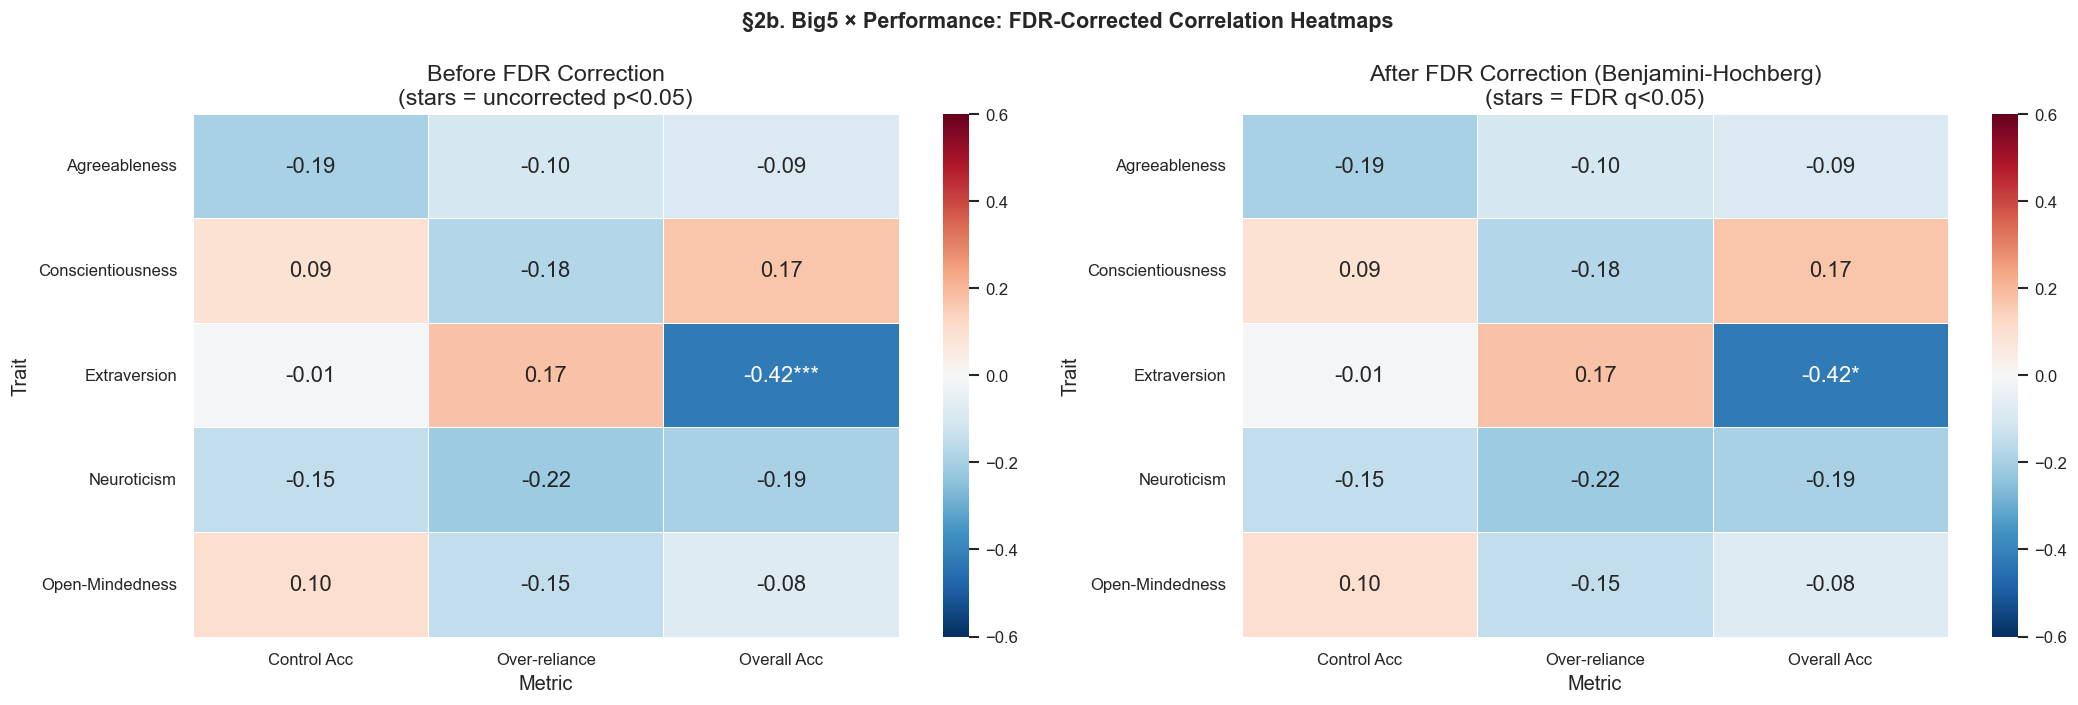

In [7]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ps = get_participant_summary(df)

traits = [
    'big5_agreeableness', 'big5_conscientiousness',
    'big5_extraversion', 'big5_neuroticism', 'big5_open_mindedness'
]
trait_labels = ['Agreeableness', 'Conscientiousness', 'Extraversion', 'Neuroticism', 'Open-Mindedness']

performance_metrics = {
    'Overall Acc':    'overall_accuracy',
    'Control Acc':    'control_accuracy',
    'Over-reliance':  'over_reliance_rate',
}

# ── Run all correlations ──
records = []
for trait, label in zip(traits, trait_labels):
    for metric_label, metric_col in performance_metrics.items():
        valid = ps[[trait, metric_col]].dropna()
        if len(valid) < 5:
            continue
        r, p = spearmanr(valid[trait], valid[metric_col])
        records.append({
            'Trait': label,
            'Metric': metric_label,
            'r': r,
            'p_raw': p,
            'n': len(valid)
        })

corr_df = pd.DataFrame(records)

# ── Apply Benjamini-Hochberg FDR ──
reject, p_adj, _, _ = multipletests(corr_df['p_raw'], alpha=0.05, method='fdr_bh')
corr_df['p_fdr'] = p_adj
corr_df['sig_raw'] = corr_df['p_raw'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)
corr_df['sig_fdr'] = corr_df['p_fdr'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)
corr_df['survives_fdr'] = corr_df['p_fdr'] < 0.05

print("§2b. Big Five × Performance: Spearman Correlations with FDR Correction")
print("     Method: Benjamini-Hochberg (q < 0.05)")
print()
print(f"{'Trait':<20} {'Metric':<16} {'r':>7} {'p_raw':>9} {'sig_raw':>8} {'p_fdr':>9} {'sig_fdr':>8} {'Survives?'}")
print("-" * 90)
for _, row in corr_df.sort_values('p_raw').iterrows():
    print(f"  {row['Trait']:<18} {row['Metric']:<16} {row['r']:+7.3f} "
          f"{row['p_raw']:9.4f} {row['sig_raw']:>8} {row['p_fdr']:9.4f} "
          f"{row['sig_fdr']:>8}  {'✓' if row['survives_fdr'] else '✗'}")

print()
surviving = corr_df[corr_df['survives_fdr']]
print(f"Findings surviving FDR correction: {len(surviving)}/{len(corr_df)}")
print()
for _, row in surviving.iterrows():
    print(f"  ✓ {row['Trait']} × {row['Metric']}: r={row['r']:+.3f}, p_fdr={row['p_fdr']:.4f}")
print()

# ── Visualization: heatmap before and after FDR ──
def make_pivot(df_in, val_col):
    return df_in.pivot(index='Trait', columns='Metric', values=val_col)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

r_pivot = make_pivot(corr_df, 'r')
p_pivot_raw = make_pivot(corr_df, 'p_raw')
p_pivot_fdr = make_pivot(corr_df, 'p_fdr')

# Annotation mask for significance
def sig_annot(r_piv, p_piv, thresh=0.05):
    annot = pd.DataFrame('', index=r_piv.index, columns=r_piv.columns)
    for t in r_piv.index:
        for m in r_piv.columns:
            try:
                r_val = r_piv.loc[t, m]
                p_val = p_piv.loc[t, m]
                stars = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
                annot.loc[t, m] = f'{r_val:.2f}{stars}'
            except: pass
    return annot

annot_raw = sig_annot(r_pivot, p_pivot_raw)
annot_fdr = sig_annot(r_pivot, p_pivot_fdr)

sns.heatmap(r_pivot, annot=annot_raw, fmt='', cmap='RdBu_r', center=0,
            vmin=-0.6, vmax=0.6, ax=axes[0], linewidths=0.5)
axes[0].set_title('Before FDR Correction\n(stars = uncorrected p<0.05)')

sns.heatmap(r_pivot, annot=annot_fdr, fmt='', cmap='RdBu_r', center=0,
            vmin=-0.6, vmax=0.6, ax=axes[1], linewidths=0.5)
axes[1].set_title('After FDR Correction (Benjamini-Hochberg)\n(stars = FDR q<0.05)')

plt.suptitle('§2b. Big5 × Performance: FDR-Corrected Correlation Heatmaps',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Neuroticism & Performance Stability

Does high neuroticism correlate with bigger accuracy drops over time?

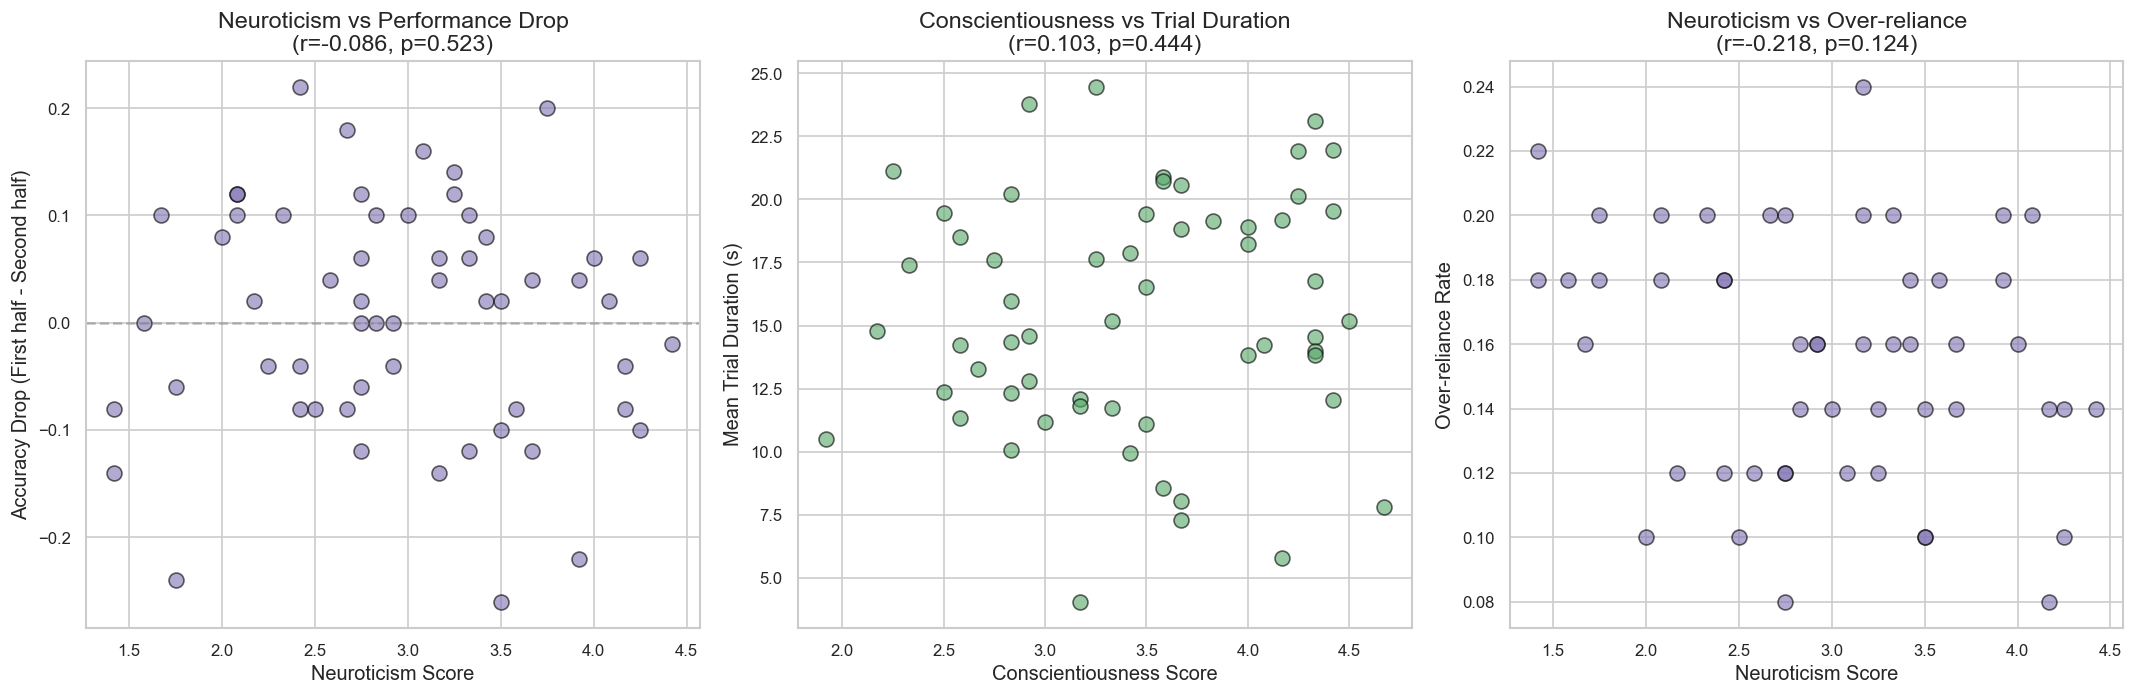

=== Statistical Tests: Personality & Stability ===
1. Neuroticism vs Accuracy Drop: Spearman r=-0.086, p=0.523
2. Conscientiousness vs Trial Duration: Spearman r=0.103, p=0.444
3. Neuroticism vs Over-reliance: Spearman r=-0.218, p=0.124


In [8]:
# Calculate per-participant performance drop: first half vs second half accuracy
# Using trial-level data
df_psycho = df[df['has_psychometrics']].copy()
df_psycho['within_phase_trial'] = ((df_psycho['trial_order'] - 1) % 50) + 1
df_psycho['half'] = df_psycho['within_phase_trial'].apply(lambda x: 'First' if x <= 25 else 'Second')

perf_stability = df_psycho.groupby(['participant_id', 'half'])['user_correct'].mean().unstack()
perf_stability['drop'] = perf_stability['First'] - perf_stability['Second']
perf_stability = perf_stability.reset_index()

# Merge with Big 5
perf_stability = perf_stability.merge(
    ps_psycho[['participant_id', 'big5_neuroticism', 'big5_conscientiousness', 'iq_score']],
    on='participant_id'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Neuroticism vs accuracy drop
axes[0].scatter(perf_stability['big5_neuroticism'], perf_stability['drop'],
              alpha=0.6, color=COLORS['over_reliance'], edgecolor='black', s=80)
r_drop, p_drop = stats.spearmanr(perf_stability['big5_neuroticism'], perf_stability['drop'])
axes[0].set_title(f'Neuroticism vs Performance Drop\n(r={r_drop:.3f}, p={p_drop:.3f})')
axes[0].set_xlabel('Neuroticism Score')
axes[0].set_ylabel('Accuracy Drop (First half - Second half)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Conscientiousness vs mean duration
axes[1].scatter(ps_psycho['big5_conscientiousness'], ps_psycho['overall_mean_duration'],
              alpha=0.6, color=COLORS['correct'], edgecolor='black', s=80)
r_dur, p_dur = stats.spearmanr(ps_psycho['big5_conscientiousness'], ps_psycho['overall_mean_duration'])
axes[1].set_title(f'Conscientiousness vs Trial Duration\n(r={r_dur:.3f}, p={p_dur:.3f})')
axes[1].set_xlabel('Conscientiousness Score')
axes[1].set_ylabel('Mean Trial Duration (s)')

# Neuroticism vs over-reliance
valid = ps_psycho[ps_psycho['over_reliance_rate'].notna()]
axes[2].scatter(valid['big5_neuroticism'], valid['over_reliance_rate'],
              alpha=0.6, color=COLORS['over_reliance'], edgecolor='black', s=80)
r_or, p_or = stats.spearmanr(valid['big5_neuroticism'], valid['over_reliance_rate'])
axes[2].set_title(f'Neuroticism vs Over-reliance\n(r={r_or:.3f}, p={p_or:.3f})')
axes[2].set_xlabel('Neuroticism Score')
axes[2].set_ylabel('Over-reliance Rate')

plt.tight_layout()
plt.show()

print('=== Statistical Tests: Personality & Stability ===')
print(f'1. Neuroticism vs Accuracy Drop: Spearman r={r_drop:.3f}, p={p_drop:.3f}')
print(f'2. Conscientiousness vs Trial Duration: Spearman r={r_dur:.3f}, p={p_dur:.3f}')
print(f'3. Neuroticism vs Over-reliance: Spearman r={r_or:.3f}, p={p_or:.3f}')


## 4. PCA & Personality Profiles

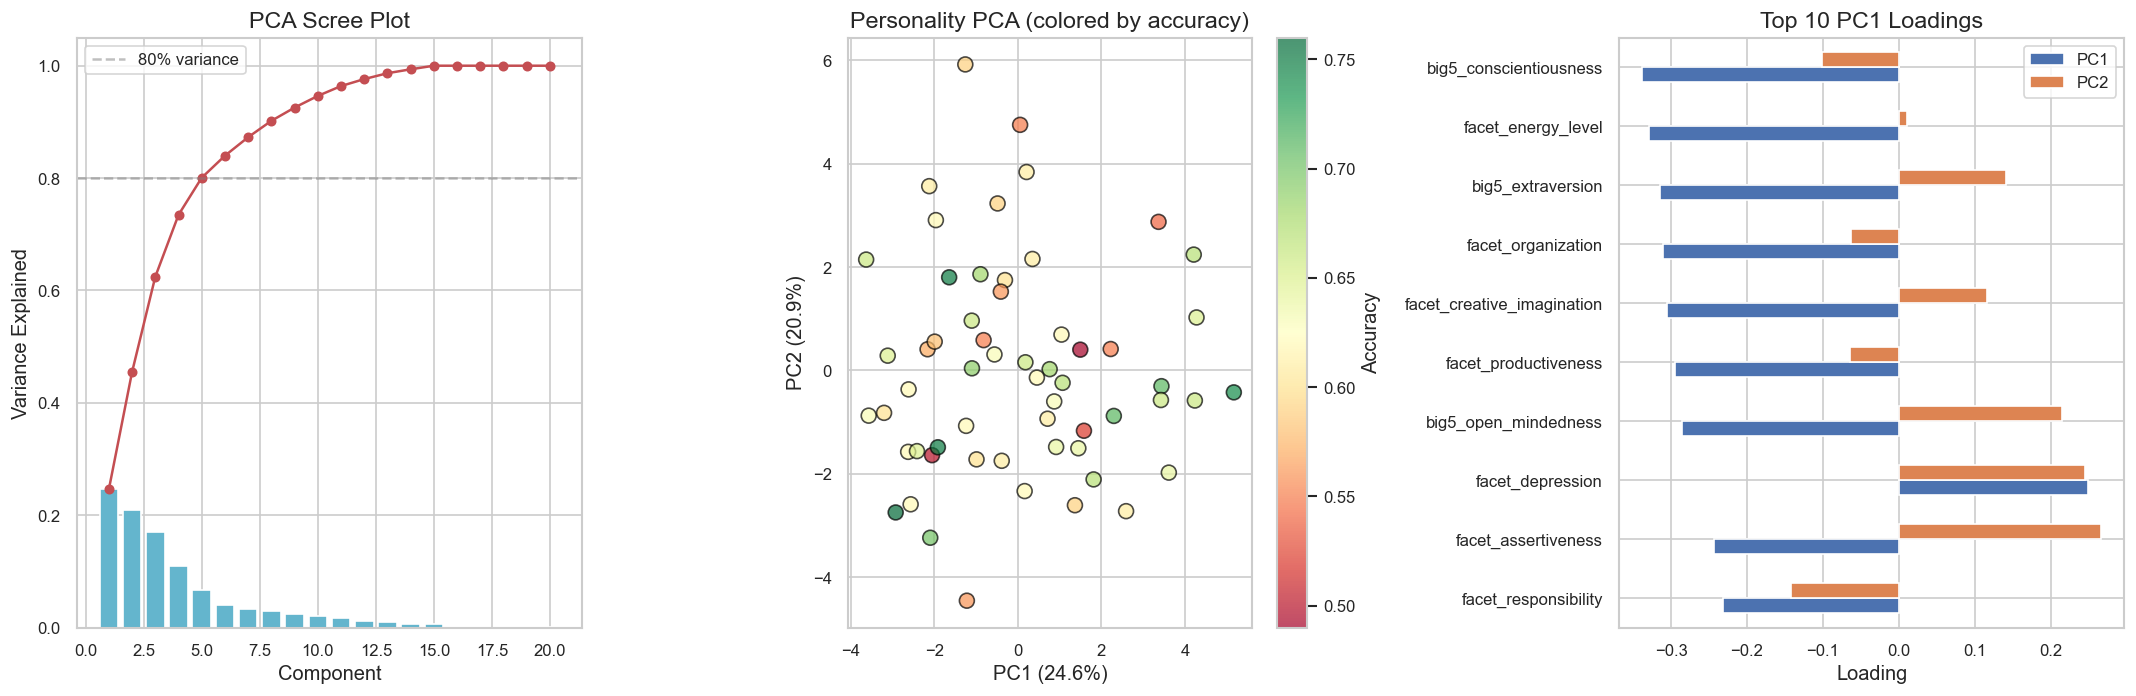

In [9]:
# PCA on Big5 + facets
facet_cols = [c for c in ps_psycho.columns if c.startswith('facet_')]
all_personality_cols = b5_cols + facet_cols

# Prepare data
pca_data = ps_psycho[all_personality_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), 
           pca.explained_variance_ratio_, color=COLORS['neutral'])
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1),
           np.cumsum(pca.explained_variance_ratio_), 'ro-', markersize=5)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('PCA Scree Plot')
axes[0].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80% variance')
axes[0].legend()

# PC1 vs PC2 scatter, colored by accuracy
valid_idx = pca_data.index
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=ps_psycho.loc[valid_idx, 'overall_accuracy'],
                          cmap='RdYlGn', s=80, edgecolor='black', alpha=0.7)
plt.colorbar(scatter, ax=axes[1], label='Accuracy')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Personality PCA (colored by accuracy)')

# Top loadings for PC1 and PC2
loadings = pd.DataFrame(
    pca.components_[:2].T, 
    columns=['PC1', 'PC2'], 
    index=all_personality_cols
)
top_loadings = loadings.reindex(loadings['PC1'].abs().sort_values(ascending=True).index)
top_loadings[-10:].plot(kind='barh', ax=axes[2], color=[COLORS['control'], COLORS['ai']])
axes[2].set_title('Top 10 PC1 Loadings')
axes[2].set_xlabel('Loading')

plt.tight_layout()
plt.show()

## 5. Exploratory Regression: Predicting Accuracy from Psychometrics

In [10]:
# OLS regression: accuracy ~ Big5 + IQ
import statsmodels.api as sm
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

reg_data = ps_psycho[['overall_accuracy'] + b5_cols + ['iq_score']].dropna()
y = reg_data['overall_accuracy']
X = reg_data[b5_cols + ['iq_score']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print('=== OLS Regression: Overall Accuracy ~ Big5 + IQ ===')
print(model.summary2().tables[1].round(4))
print(f'\nR² = {model.rsquared:.3f}, Adj. R² = {model.rsquared_adj:.3f}')
print(f'F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.3f}, p = {model.f_pvalue:.4f}')
print(f'n = {len(reg_data)}')
print(f'\n⚠️  Interpret with caution at n={len(reg_data)}. Exploratory only.')

# --- NEW: Multicollinearity Diagnostics (VIF) ---
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF Score"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print('\n=== Multicollinearity Test (Variance Inflation Factor) ===')
# Drop the 'const' row from the printout since the intercept's VIF is irrelevant
print(vif_data[vif_data['Feature'] != 'const'].round(2).to_string(index=False))
print('\nDiagnostics: VIF < 5 is good. VIF > 5 indicates problematic multicollinearity.')


=== OLS Regression: Overall Accuracy ~ Big5 + IQ ===
                         Coef.  Std.Err.        t   P>|t|  [0.025  0.975]
const                   0.8444    0.0778  10.8558  0.0000  0.6883  1.0006
big5_agreeableness     -0.0307    0.0134  -2.2867  0.0264 -0.0576 -0.0037
big5_conscientiousness  0.0217    0.0109   1.9947  0.0514 -0.0001  0.0434
big5_extraversion      -0.0477    0.0111  -4.2921  0.0001 -0.0700 -0.0254
big5_neuroticism       -0.0205    0.0097  -2.1131  0.0395 -0.0400 -0.0010
big5_open_mindedness    0.0127    0.0129   0.9878  0.3279 -0.0132  0.0386
iq_score               -0.0033    0.0043  -0.7684  0.4458 -0.0119  0.0053

R² = 0.331, Adj. R² = 0.252
F(6, 51) = 4.207, p = 0.0016
n = 58

⚠️  Interpret with caution at n=58. Exploratory only.

=== Multicollinearity Test (Variance Inflation Factor) ===
               Feature  VIF Score
    big5_agreeableness       1.10
big5_conscientiousness       1.30
     big5_extraversion       1.28
      big5_neuroticism       1.25
  big

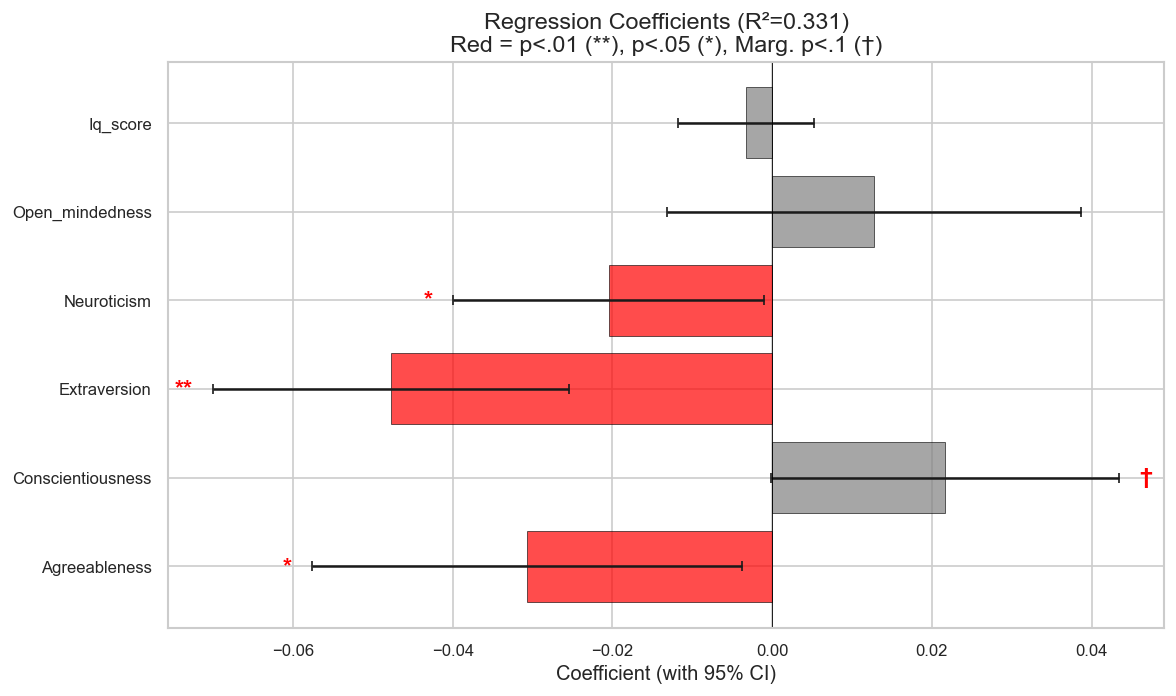

In [11]:
# Visualization: regression coefficients
fig, ax = plt.subplots(figsize=(10, 6))

coefs = model.params.drop('const')
ci = model.conf_int().drop('const')
p_values = model.pvalues.drop('const')
errors = np.abs(ci.values - coefs.values[:, None]).T

colors = ['red' if p < 0.05 else 'gray' for p in p_values]

y_pos = range(len(coefs))
ax.barh(y_pos, coefs.values, xerr=errors, color=colors, alpha=0.7,
       capsize=3, edgecolor='black', linewidth=0.5)

# Add significance stars dynamically at the tip of the error bars
for i, (coef, pval) in enumerate(zip(coefs.values, p_values.values)):
    # Determine the star symbol
    if pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    elif pval < 0.1:
        star = '†'
    else:
        star = ''
        
    if star:
        ci_lower, ci_upper = ci.values[i]
        offset = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.02
        if coef >= 0:
            ax.text(ci_upper + offset, i, star, va='center', ha='left', 
                    fontsize=14, fontweight='bold', color='red')
        else:
            ax.text(ci_lower - offset, i, star, va='center', ha='right', 
                    fontsize=14, fontweight='bold', color='red')

ax.set_yticks(y_pos)
ax.set_yticklabels([c.replace('big5_', '').capitalize() for c in coefs.index])
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (with 95% CI)')
ax.set_title(f'Regression Coefficients (R²={model.rsquared:.3f})\nRed = p<.01 (**), p<.05 (*), Marg. p<.1 (†)')

plt.tight_layout()
plt.show()


## Findings & Next Steps

**Summarize after running:**

1. IQ=0 group characteristics and performance implications
2. Big5 correlates of performance (any significant personality predictors?)
3. Neuroticism → performance stability link
4. Conscientiousness → engagement/duration link
5. PCA personality profiles and their relation to accuracy
6. Regression model: how much variance explained?

**Next**: NB5 for integrated mixed-effects models combining all dimensions.